In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image

%matplotlib inline
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

**R** : En este ítem se aplicó únicamente un "dropna" a la base de datos, siendo esta la única limpieza realizada. Además dadas las características de los datos, no fue necesario eliminar valores atípicos de nuestras variables.

In [2]:
# Cargamos la base de datos
df_juna = pd.read_csv("junaeb3.csv", sep=",")
df_juna.dropna(inplace=True)
df_stepmix = df_juna.copy()

In [3]:
df_juna.dtypes

sexo            int64
edad            int64
imce          float64
vive_padre      int64
vive_madre      int64
sk1             int64
sk2             int64
sk3             int64
sk4             int64
sk5             int64
sk6             int64
sk7             int64
sk8             int64
sk9             int64
sk10            int64
sk11            int64
sk12            int64
sk13            int64
act_fisica    float64
area            int64
educm         float64
educp           int64
madre_work      int64
dtype: object

In [ ]:
df_juna.describe()

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,29696.000000,29696.000000,29696.00000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,...,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000
mean,0.539164,82.544450,1.01826,0.720097,0.975990,1.108533,1.386651,1.256802,1.250943,1.264749,...,1.326307,1.844693,1.379108,1.495858,1.687298,2.556270,0.911705,13.106311,13.001785,0.106917
std,0.498472,4.295051,1.36947,0.449559,0.164329,0.379168,0.643343,0.575636,0.569647,0.558138,...,0.655108,0.933154,0.660226,0.790316,0.979401,1.067923,0.283728,3.328273,3.418317,0.941629
min,0.000000,62.000000,-5.02000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.12000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.98000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,1.000000
75%,1.000000,82.000000,1.93000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,15.000000,1.000000
max,1.000000,107.000000,5.04000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero óptimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

**R**: En esta pregunta se puede apreciar los coeficientes factoriales en dónde cada fila de la matriz que engloba estos coeficientes representa a cada varible "sk" y cada columna un factor estraído, cabe destcar que no se considero "sk7" para nuestro análisis. En base los resultados obtenidos se pudo definir la característica de cada factor en dónde obtuvimos: 

F1 = ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
Este factor refleja la "creatividad", al agrupar ítems que miden la capacidad de generar ideas originales y soluciones innovadoras.

F2 = ['sk1', 'sk2', 'sk3', 'sk4']
Este factor captura la "expresividad", incluyendo indicadores que evalúan cómo se comunican y manifiestan las emociones y pensamientos.

F3 = ['sk5', 'sk6', 'sk8']
Este factor representa la "sociabilidad", al reunir ítems que valoran la predisposición a interactuar y establecer vínculos con otros.


En lo anterior debemos tener encuenta que cada "sk" se asigno a cada factor según la comparación de que factor obtuvo el mayor valor en su coeficiente factorial.

También, determinamos las comunalidades de nuestras variables "sk", en donde un valor cercano a 1 implica una variable bien explicada por el modelo y un valor cercano a cero indica lo contrario. Para las variables sk6, sk8, sk9 y sk10 habría que poner un poco de ojo y verificar si es que tienen una buena representación dentro del modelo.

Por último gracias a la ayuda de "eigenvalues, _ = fa.get_eigenvalues()" se determino el número óptimo de factores, en donde determinamos que 3 factores es el adecuado, esto se determino viendo los valores arrojados mayores a 1. Asimismo se utilizo el método del codo para válidar el resultado y determinar el número de factores apropiados, obteniendo un visualización no tan clara del número óptimo de factores, aunque si se observó que iban desde 3 a 4 factores.




In [ ]:
df_sk = df_juna[['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13']]
fa = FactorAnalyzer(rotation='oblimin').fit(df_sk)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.025091, 0.592769, -0.036490],
       [0.014132, 0.504176, 0.201440],
       [0.015141, 0.633897, -0.014981],
       [0.001552, 0.742733, -0.011935],
       [-0.030999, 0.020518, 0.804761],
       [0.081477, 0.098873, 0.419382],
       [0.231480, -0.072300, 0.454024],
       [0.502530, 0.074356, 0.049459],
       [0.610043, -0.023017, -0.033028],
       [0.704005, 0.033629, 0.005354],
       [0.570888, -0.038834, 0.007890],
       [0.508570, 0.028714, -0.008627]])

In [6]:
eigenvalues, _ = fa.get_eigenvalues()
print(eigenvalues)

[4.003739 1.347633 1.089935 0.802648 0.743580 0.706589 0.691043 0.610450
 0.531272 0.519068 0.491722 0.462321]


In [7]:
fa.get_communalities()

array([0.353336, 0.294971, 0.402279, 0.551797, 0.649022, 0.192296,
       0.264948, 0.260512, 0.373773, 0.496782, 0.327484, 0.259543])

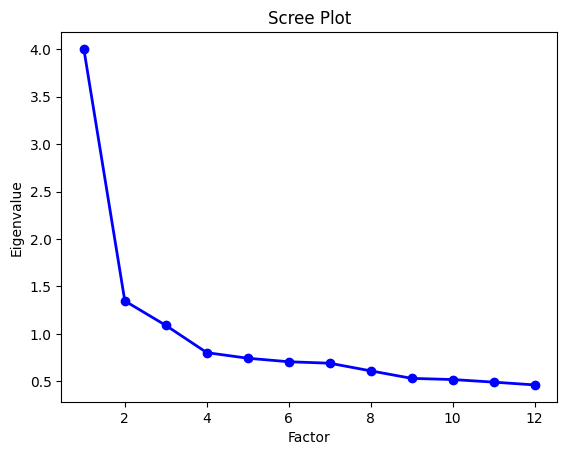

In [8]:
values = np.arange(1,13)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

**R**: Según los resultados obtenidos de la influncia de los factores sobre las variables a caracterizar, obtuvimos el siguiente análisis:

Sexo: Para la variable "sexo" según lo visualizado en los gráficos, se dertemina que no exite una relación clara entre los factores y está variable, por ende no se puede establecer una diferenciación y definición clara de alguna tendencia o influencia de está variable sobre los factores.

ÁREA (Urbana/Rural): En está variable vemos una interpretación similar a la anterior, ya que parece que existiera una cierta dispersión entre los factores, pero no se logra ver una separación notoria entre los grupos para los 3 factores.

IMCE: Los gráficos asociados a la variable IMCE (Índice de Masa corporal Estandarizado) muestran una interpretación similar a las anteriores y se concluye que no se observa una diferenciación clara entre las categorías de los 3 factores.

Actividad Física: En esta variable sucede algo parecido no se presencia una separación clara que indique una tendencia en la dispersión de los 3 factores.

En conclusión, estos resultados se pueden deber a diversos factores, pero unos de los más comunes es que quizás en nuestra muestra existen comportamientos similares entre las personas analizadas, lo que implica en no poder observar una diferenciación clara. También es importante considerar que esto se puede deber a que los factores selecionados no discrimina de la mejor manera las clases, viendose esto reflejado en los gráficos realizados y pudiendo intuir que nuestros factores seleccionados no logran capturar de la mejor forma las variaciones que distinguen las clases.

In [ ]:
# Supongamos que 'df_sk' es tu DataFrame con las variables originales que usaste para el análisis
factores = fa.transform(df_sk)

# Convertimos las puntuaciones de los factores en un DataFrame
factores_df = pd.DataFrame(factores, columns=["Factor 1", "Factor 2", "Factor 3"])

# Agregamos estos factores al DataFrame original
df_juna['Factor 1'] = factores_df['Factor 1']
df_juna['Factor 2'] = factores_df['Factor 2']
df_juna['Factor 3'] = factores_df['Factor 3']

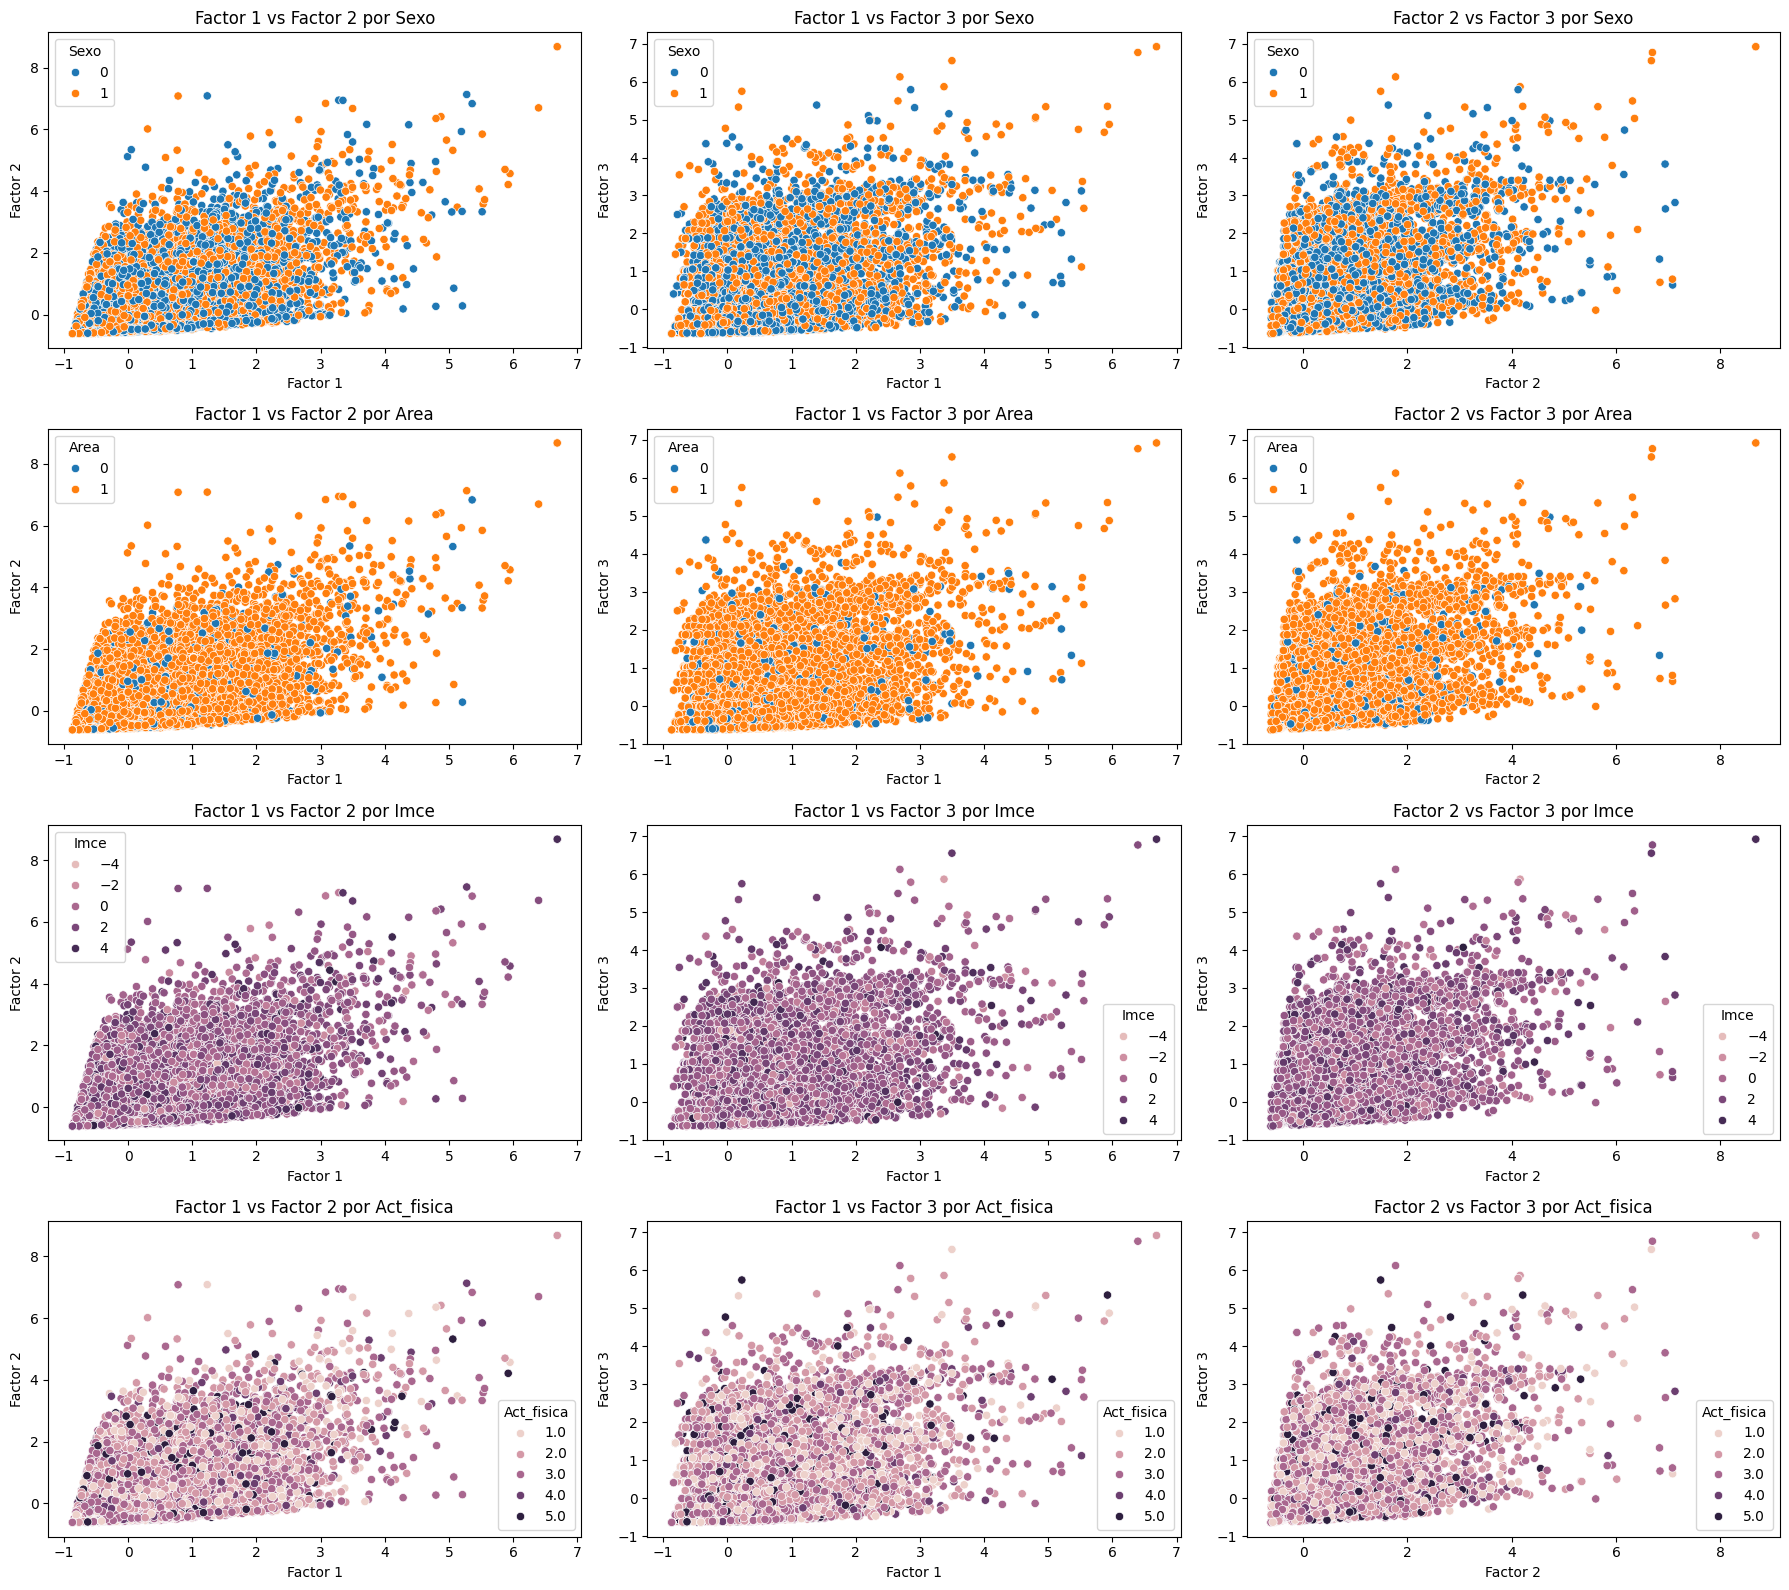

In [ ]:
# Lista de las variables de caracterización
Variables = ['sexo', 'area', 'imce', 'act_fisica']

# Definimos el número de filas y columnas para los subgráficos
# En este caso, asumimos 4 variables y 3 combinaciones de factores por variable
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iteramos sobre las variables y graficar en los subgráficos
for idx, var in enumerate(Variables):
    # Graficamos el Factor 1 vs Factor 2, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df_juna, x='Factor 1', y='Factor 2', hue=var, ax=axes[idx*3])
    axes[idx*3].set_title(f'Factor 1 vs Factor 2 por {var.capitalize()}')
    axes[idx*3].set_xlabel('Factor 1')
    axes[idx*3].set_ylabel('Factor 2')
    axes[idx*3].legend(title=var.capitalize())

    # Graficamos el Factor 1 vs Factor 3, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df_juna, x='Factor 1', y='Factor 3', hue=var, ax=axes[idx*3 + 1])
    axes[idx*3 + 1].set_title(f'Factor 1 vs Factor 3 por {var.capitalize()}')
    axes[idx*3 + 1].set_xlabel('Factor 1')
    axes[idx*3 + 1].set_ylabel('Factor 3')
    axes[idx*3 + 1].legend(title=var.capitalize())

    # Graficamos el Factor 2 vs Factor 3, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df_juna, x='Factor 2', y='Factor 3', hue=var, ax=axes[idx*3 + 2])
    axes[idx*3 + 2].set_title(f'Factor 2 vs Factor 3 por {var.capitalize()}')
    axes[idx*3 + 2].set_xlabel('Factor 2')
    axes[idx*3 + 2].set_ylabel('Factor 3')
    axes[idx*3 + 2].legend(title=var.capitalize())

# Ajustamos el layout para que los gráficos no se solapen
plt.tight_layout()

# Mostramos los gráficos
plt.show()

4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

**R**: Gracias el análisis de la pregunta 2 en la pregunta 4 pudimos determinar de forma corecta los "sk" asigandos a cada "factor", además definimos los nombres en base las características que tenían en comúnos los sk que contenia el factor. Para el factor 1 le asignamos el atributo característico de una persona que es "cretiva", para el factor 2 se le caracterizo como una persona que es "expresiva" y en el factor 3 una persona que se caracteriza por ser "sociable".

En relación a las características de las variables (sk) sobre su factor latente (creativo, expresivo, sociable), podemos ver que nuestras variables actuan de forma correcta sobre sus factores con valores iguales a 1 o mayores a 1 en casi todos los casos, esto indica que las variables explican de forma correcta la variabilidad del factor.

Con respecto a los índices de ajuste del modelo tenemos los siguientes resultados:

TLI: Se obtuvo un valor de aprocimadamente 0.93, este valor es cercano lo que indica un buen ajuste del modelo.
CFI: Tenemos un resultado de aproximadamente 0.4, siendo un valor cercano a 1 y indicando que el modelo se ajusta bien a los datos.
RMSEA: Valor de aproximadamente 0.05, este valor es menor que 0.08 lo que refleja un ajuste razonable o bueno.

En conclusión nuestros factores latentes se ajustan bien al modelo y la correlación de las variables sobre sus factores logra explicar de forma correcta la variabilidad de los factores latentes. Además que los valores p indican que todas nuestras variables son significativas, esto debido a que el valor-p < 0.05.

In [ ]:
F1 = ['sk9', 'sk10', 'sk11', 'sk12', 'sk13'] # Creativo
# Este factor refleja la "creatividad", al agrupar ítems que miden la capacidad de generar ideas originales y soluciones innovadoras.

F2 = ['sk1', 'sk2', 'sk3', 'sk4'] # Expresivo
# Este factor captura la "expresividad", incluyendo indicadores que evalúan cómo se comunican y manifiestan las emociones y pensamientos.

F3 = ['sk5', 'sk6', 'sk8'] # Sociable
# Este factor representa la "sociabilidad", al reunir ítems que valoran la predisposición a interactuar y establecer vínculos con otros.

In [12]:
mod = """ 
# measurement model
Creativo =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresivo =~ sk1 + sk2 + sk3 + sk4
Sociable =~ sk5 + sk6 + sk8
    """
model = semopy.Model(mod)
out=model.fit(df_juna)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.051 0.091 0.049 0.161 0.057 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [13]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,Creativo,1.000000,0.594425,-,-,-
1,sk10,~,Creativo,1.348296,0.562596,0.01854,72.725071,0.0
2,sk11,~,Creativo,1.247906,0.736003,0.014736,84.684717,0.0
3,sk12,~,Creativo,1.097330,0.540702,0.015523,70.692694,0.0
4,sk13,~,Creativo,1.273586,0.506374,0.018913,67.339241,0.0
5,sk1,~,Expresivo,1.000000,0.582652,-,-,-
6,sk2,~,Expresivo,1.876642,0.644548,0.023793,78.87212,0.0
7,sk3,~,Expresivo,1.646084,0.631816,0.021121,77.934883,0.0
8,sk4,~,Expresivo,1.845637,0.715782,0.022169,83.253688,0.0
9,sk5,~,Sociable,1.000000,0.718118,-,-,-


In [ ]:
# Inspeccionamos los parámetros del modelo para obtener las cargas factoriales
est = model.inspect(mode='list', what="names", std_est=True)

# Filtramos las cargas factoriales
loadings = est[est.op == '~']  # Aquí, '~' indica las relaciones entre los factores y las variables observadas
print("Cargas factoriales (loadings):")
print(loadings[['lval', 'op', 'rval', 'Estimate']].to_string(index=False))

Cargas factoriales (loadings):
lval op      rval  Estimate
 sk9  ~  Creativo  1.000000
sk10  ~  Creativo  1.348296
sk11  ~  Creativo  1.247906
sk12  ~  Creativo  1.097330
sk13  ~  Creativo  1.273586
 sk1  ~ Expresivo  1.000000
 sk2  ~ Expresivo  1.876642
 sk3  ~ Expresivo  1.646084
 sk4  ~ Expresivo  1.845637
 sk5  ~  Sociable  1.000000
 sk6  ~  Sociable  1.019985
 sk8  ~  Sociable  1.158490


In [15]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

**R** Para calcular el número óptimo de clusters, se utilizó el modelo "StepMix". El proceso comenzó con la creación de un gráfico de línea que muestra cómo varía el valor del "BIC" a medida que cambia el número de clusters. En el gráfico, el eje x representa la cantidad de clusters y el eje y muestra el valor del "BIC". Aunque la visualización no permite identificar de manera clara el número exacto de clusters óptimos, sí se puede observar que el gráfico sugiere un rango de entre 3 y 4 clusters como el más adecuado.

Después de generar el gráfico de líneas, corrimos el modelo "StepMix" con diferentes números de clusters, con el objetivo de determinar de manera más precisa la cantidad óptima. Al analizar los resultados, observamos que el valor del "BIC" disminuía y el valor de la "Entropía" aumentaba, lo que nos llevó a concluir que el número óptimo de clusters sería n = 4. Sin embargo, al examinar la distribución de los datos por cluster para ese valor, notamos que uno de los grupos tenía muy pocos datos. Por esta razón, se optó por una cantidad óptima de 3 clusters.

Por último en relación al análisis de las diferencias de los cluster de forma gráfica, notamos que:

Cluster 1: Para este cluster 1 se tuvo un valor en la media del "imce" igual a -1.949, esto indica que en promedio las personas de ese cluster se encuentra en bajo peso y en sus extremos tenemos personas cercanas a la desnutrición.

Cluster 2: En esta situación se obtuvo un valor de 2.4056, lo que indica que en promedio las personas de este cluster se encuentran sobre peso y para su valor estremo en la cola superior vemos que concentra a personas con obesidad.

Cluster 3: Aquí en el cluster 3 se obtuvo un valor de 0.5984, mostrando que en este cluster en promedio encontramos a personas que estan en condiciones normales de peso y en sus extremos podemos encontrar a personas con bajo peso o con sobre peso.

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.18it/s, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.34s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:12<00:00, 12.29s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Python\Python311\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:15<00:00, 15.65s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Python\Python311\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


<Axes: >

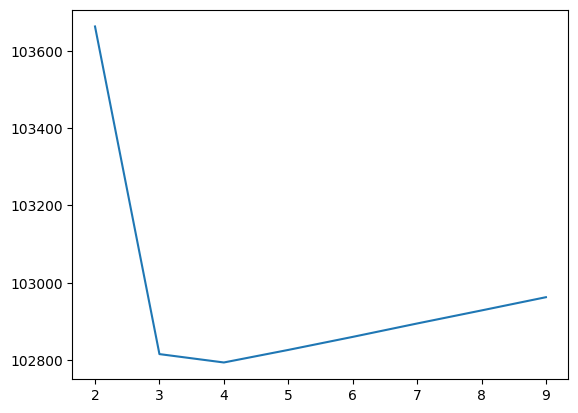

In [16]:
from stepmix.stepmix import StepMix

df_imce = df_stepmix[['imce']]
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df_imce)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df_imce))

sns.lineplot(x = K, y = BIC) 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from stepmix.stepmix import StepMix

# Listas para almacenar los resultados de BIC, AIC y entropía
BIC = []
AIC = []
entropy = []

# Crear un ciclo para ajustar modelos con n_components de 1 a 5
for n_components in range(2, 6):
    # Ajustar el modelo StepMix para cada número de componentes
    model = StepMix(n_components=n_components, measurement="gaussian", verbose=1, random_state=123).fit(df_imce)
    
    # Almacenamos el BIC, AIC y la entropía del modelo
    BIC.append(model.sabic(df_imce))  # BIC a
    AIC.append(model.aic(df_imce))    # AIC
    entropy.append(model.entropy(df_imce))   # Entropía

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.09it/s, max_LL=-5.18e+4, max_avg_LL=-1.74]


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit        
          class_no                   0       1
          param variable                      
          means imce            2.1253  0.3252
    Class weights
        Class 1 : 0.38
        Class 2 : 0.62
    Fit for 2 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 2
    Number of estimated parameters: 3
    Log-likelihood (LL)           : -51805.1501
    -2LL                          : 103610.3002
    Average LL                    : -1.7445
    AIC                           : 103616.30
    BIC                           : 103641.20
    CAIC                          : 103644.20
    Sample-Size Adjusted BIC      : 103662.56
    Entropy                       : 11728.9291
    Scaled Relative Entropy       : 0.4302
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.40s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.36s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Python\Python311\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce             1.173  2.7111 -2.5822  0.1384
    Class weights
        Class 1 : 0.49
        Class 2 : 0.16
        Class 3 : 0.01
        Class 4 : 0.35
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -51336.0764
    -2LL                          : 102672.1527
    Average LL                    : -1.7287
    AIC                           : 102686.15
    BIC                           : 102744.24
    CAIC                          : 102751.24
    Sample-Size Adjusted BIC      : 102794.09
    Entropy                       : 22265.7966
    Scaled Relative Entropy    

Initializations (n_init) : 100%|██████████| 1/1 [00:09<00:00,  9.04s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                                
          class_no                   0       1       2       3       4
          param variable                                              
          means imce           -2.7033  2.6755  0.7973  1.1757 -0.0542
    Class weights
        Class 1 : 0.01
        Class 2 : 0.17
        Class 3 : 0.26
        Class 4 : 0.33
        Class 5 : 0.22
    Fit for 5 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 5
    Number of estimated parameters: 9
    Log-likelihood (LL)           : -51334.8865
    -2LL                          : 102669.7730
    Average LL                    : -1.7287
    AIC                           : 102687.77
    BIC                           : 102762.46
    CAIC                          : 102771.46
    Sample-Size Adjusted BIC      : 102826.55
    Entropy            


c:\Python\Python311\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


In [ ]:
# Imprimimos los resultados de BIC con un formato más estructurado
print(f'BIC para 2 clusters: {BIC[0]:.4f}')
print(f'BIC para 3 clusters: {BIC[1]:.4f}')
print(f'BIC para 4 clusters: {BIC[2]:.4f}')
print(f'BIC para 5 clusters: {BIC[3]:.4f}')
print(f'AIC para 2 clusters: {AIC[0]:.4f}')
print(f'AIC para 3 clusters: {AIC[1]:.4f}')
print(f'AIC para 4 clusters: {AIC[2]:.4f}')
print(f'AIC para 5 clusters: {AIC[3]:.4f}')
print(f'Entropia para 2 clusters: {entropy[0]:.4f}')
print(f'Entropia para 3 clusters: {entropy[1]:.4f}')
print(f'Entropia para 4 clusters: {entropy[2]:.4f}')
print(f'Entropia para 5 clusters: {entropy[3]:.4f}')

BIC para 2 clusters: 103662.5589
BIC para 3 clusters: 102815.7480
BIC para 4 clusters: 102794.0896
BIC para 5 clusters: 102826.5489
AIC para 2 clusters: 103616.3002
AIC para 3 clusters: 102738.6503
AIC para 4 clusters: 102686.1527
AIC para 5 clusters: 102687.7730
Entropia para 2 clusters: 11728.9291
Entropia para 3 clusters: 11499.4902
Entropia para 4 clusters: 22265.7966
Entropia para 5 clusters: 32318.6808


In [ ]:
# Continuous StepMix Model with 3 latent classes
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)

# Fit model and predict clusters
model.fit(df_imce)
df_imce['pred']=model.predict(df_imce)

# Entre -1 y 1 peso normal

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.92s/it, max_LL=-8.25e+4, max_avg_LL=-2.78]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce           -2.5512  0.5463  2.8145
                pred            2.2482  2.9556  1.0933
    Class weights
        Class 1 : 0.01
        Class 2 : 0.76
        Class 3 : 0.23
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -82535.2020
    -2LL                          : 165070.4040
    Average LL                    : -2.7793
    AIC                           : 165086.40
    BIC                           : 165152.79
    CAIC                          : 165160.79
    Sample-Size Adjusted BIC      : 165209.76
    Entropy                       : 3435.4166
    Scaled Relative Entropy     


C:\Users\quilo\AppData\Local\Temp\ipykernel_20624\1234914821.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_imce['pred']=model.predict(df_imce)


,imce,pred
1,0.71,1
3,2.05,2
4,1.05,1
5,1.39,1
6,2.75,2
...,...,...
31050,1.63,1
31051,2.57,2
31052,2.12,2
31053,-0.43,1


C:\Users\quilo\AppData\Local\Temp\ipykernel_20624\3980016441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


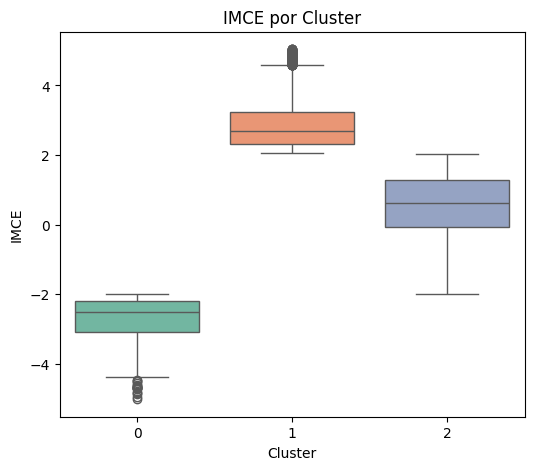

In [20]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x='pred', 
    y='imce', 
    data=df_imce, 
    palette='Set2'
)
plt.title('IMCE por Cluster')
plt.xlabel('Cluster')
plt.ylabel('IMCE')
plt.show()

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

**R**: Para la selección de las variables que representaran al imce en el modelo estructural, se considero un análisis de prueba una a una, en dónde se iba viendo su significancia dentro del modelo (valor-p) y además su correlación con la variable "imce". Una vez que se tuvo todas las variables en su conjunto se analizo su significancia en relación al (valor-p) y se eliminaron las que no eran significativas, así quedando las variables que mejor se ajustan al modelo.

Podemos ver que el modelo SEM indica que las relaciones entre las variables observadas y los factores latentes (Creativo, Expresivo, Sociable) son muy fuertes y significativas, ya que sus valores p son menores a 0.05. Esto significa que las conexiones entre ellos son fuertes. Las cargas factoriales también son altas, lo que confirma que variables como sk9, sk10, sk11, entre otras, están bien relacionadas con los factores. Además, los factores Sociable y Expresivo tienen un impacto importante sobre imce, junto con otras variables como sexo y área. Aunque los factores están relacionados entre sí, esas relaciones son débiles, lo que sugiere que cada uno captura algo único por separado. En resumen, el modelo se ajusta bastante bien a los datos, explicando claramente cómo se relacionan las variables y los factores. Esto refleja que es un modelo confiable y fácil de interpretar.

Finalmente en relación a los índices de ajuste tenemos los siguiente resultados y interpretaciones:

TLI: Se obtuvo un valor de aproXimadamente de 0.897, este valor es cercano 0,9 lo que indica un buen ajuste del  modelo, aunque lo ideal sería tener un valor igual a 0.9 o mayor, ya que el valor obtenido indica poner atención en el ajuste del modelo.

CFI: Tenemos un resultado de aproximadamente 0.880, siendo un valor menor  0.9 a 1 indicando que el modelo se ajusta más o menos a los datos, pero siendo estrictos el ajuste no es bueno.

RMSEA: Valor de aproximadamente 0.045, este valor es menor que 0.08 lo que refleja un ajuste razonable o bueno del modelo.


In [ ]:
# Analizaremo una a una las variables en el modelo para ver su significancia dentro de este mismo y vemos la influencia que tiene cada variable sobre la estudiada
# en base lo anterior veremos con que variables nos quedaremos, cosniderando solo a las que sean significativas con valor de p < 0.05.
# # sexo + edad + vive_padre + vive_madre + act_fisica + area + educm + educp + madre_work

In [39]:
df_sem = pd.read_csv("junaeb3.csv", sep=",")
df_sem = df_sem.dropna()
df_cluster1 = df_sem.copy() # Para la pregunta 7
df_cluster2 = df_sem.copy() # Para la pregunta 7
df_cluster3 = df_sem.copy() # Para la pregunta 7

In [40]:
modelo_sem = """
# Measurement Part
Creativo =~ sk9 + sk10 + sk11 + sk12 + sk13
Expresivo =~ sk1 + sk2 + sk3 + sk4
Sociable =~ sk5 + sk6 + sk8
# Structural model
imce ~ Creativo + Sociable + Expresivo + sexo + area + act_fisica + educm + educm + madre_work
    """
model = semopy.Model(modelo_sem)
out=model.fit(df_sem)
print(out)
print(model.inspect())

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.333
Number of iterations: 51
Params: 1.347 1.247 1.097 1.273 1.879 1.647 1.848 1.020 1.160 -0.043 0.244 -0.313 0.135 -0.149 -0.026 -0.013 0.045 0.152 0.051 0.091 0.049 0.161 0.057 1.861 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.373 0.469 0.277
         lval  op        rval  Estimate  Std. Err     z-value   p-value
0         sk9   ~    Creativo  1.000000         -           -         -
1        sk10   ~    Creativo  1.347318  0.018525   72.729585       0.0
2        sk11   ~    Creativo  1.247400  0.014724   84.716232       0.0
3        sk12   ~    Creativo  1.097399  0.015515   70.729876       0.0
4        sk13   ~    Creativo  1.272744    0.0189   67.339861       0.0
5         sk1   ~   Expresivo  1.000000         -           -         -
6         sk2   ~   Expresivo  1.878844  0.023823   78.866348       0.0
7         sk3   ~   Expresivo  1.64

In [41]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,9901.556816,0.0,90491.013743,0.891883,0.89058,0.871938,0.89058,0.873463,0.049359,71.333139,370.088774,0.333431


-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

**R**: En conclusión, para esta pregunta observamos que la relación entre la variable dependiente y las variables independientes no fue tan significativa en algunas situaciones del análisis para cada submuestra generada a partir de las clases latentes. Por ejemplo, en la generación del modelo basado en los datos del clúster 1, vemos que las variables sexo y área no son significativas, posiblemente debido a la pequeña cantidad de datos que contiene. En el clúster 2, sexo y área sí son significativas, pero actividad física no lo es, lo que podría ser porque el clúster 2 tiene más datos en relación con el clúster 1, que cuenta con aproximadamente 400 datos. Para el clúster 3, área, actividad física y madre trabaja no son significativas, a pesar de que es el clúster con más datos. En cuanto a las variables de ajuste de bondad (CFI, TLI y RMSEA), no cambian mucho entre los tres modelos, con valores promedio de 0.89, 0.87 y 0.05, respectivamente. Aunque estos resultados son buenos, en comparación con el modelo grupal son deficientes, lo que indica que no hay una ganancia al realizar el modelo por grupos. Según los resultados obtenidos por las variables significativas y los índices de bondad de ajuste, recomendaría realizar todo de forma agrupada y no individual.

In [42]:
# Datos segmento 1
df_cluster1['segmentos'] = df_imce['pred']
df_cluster1 = df_cluster1[df_cluster1['segmentos'] == 0].copy()

model = semopy.Model(modelo_sem)
out=model.fit(df_cluster1)
print(out)
print(model.inspect())

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.761
Number of iterations: 53
Params: 1.062 1.193 0.889 1.067 2.718 2.699 3.002 1.089 1.485 0.071 -0.241 0.392 -0.117 0.180 0.113 0.028 0.010 0.224 0.038 0.081 0.019 0.149 0.037 0.449 0.080 0.682 0.231 0.368 0.814 0.264 0.186 0.118 0.167 0.412 0.555 0.331
         lval  op        rval  Estimate  Std. Err    z-value   p-value
0         sk9   ~    Creativo  1.000000         -          -         -
1        sk10   ~    Creativo  1.061537  0.141556   7.499061       0.0
2        sk11   ~    Creativo  1.192629  0.124871   9.550869       0.0
3        sk12   ~    Creativo  0.888879   0.11026   8.061636       0.0
4        sk13   ~    Creativo  1.066512  0.149641   7.127151       0.0
5         sk1   ~   Expresivo  1.000000         -          -         -
6         sk2   ~   Expresivo  2.717945  0.426616    6.37094       0.0
7         sk3   ~   Expresivo  2.699068  0.406

In [43]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,247.398543,1.256643e-08,1131.088412,0.884493,0.781274,0.744009,0.781274,0.864814,0.050692,70.477547,206.695254,0.761226


In [44]:
# Datos segmento 2
df_cluster2['segmentos'] = df_imce['pred']
df_cluster2 = df_cluster2[df_cluster2['segmentos'] == 1].copy()

model = semopy.Model(modelo_sem)
out=model.fit(df_cluster2)
print(out)
print(model.inspect())

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.330
Number of iterations: 45
Params: 1.343 1.248 1.084 1.244 1.888 1.684 1.895 1.036 1.174 -0.008 0.019 -0.068 -0.026 -0.078 -0.004 -0.003 0.020 0.150 0.051 0.089 0.047 0.153 0.055 0.836 0.095 0.586 0.195 0.435 0.703 0.241 0.195 0.158 0.147 0.365 0.451 0.279
         lval  op        rval  Estimate  Std. Err     z-value   p-value
0         sk9   ~    Creativo  1.000000         -           -         -
1        sk10   ~    Creativo  1.343391  0.021294   63.086793       0.0
2        sk11   ~    Creativo  1.248322  0.016991   73.469839       0.0
3        sk12   ~    Creativo  1.083534  0.017753   61.035473       0.0
4        sk13   ~    Creativo  1.244338  0.021537   57.777104       0.0
5         sk1   ~   Expresivo  1.000000         -           -         -
6         sk2   ~   Expresivo  1.888376  0.027693   68.188474       0.0
7         sk3   ~   Expresivo  1.6

In [45]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,7422.345503,0.0,68504.929109,0.893377,0.891652,0.873193,0.891652,0.875212,0.04897,71.340558,360.123895,0.329721


In [46]:
# Datos segmento 3
df_cluster3['segmentos'] = df_imce['pred']
df_cluster3 = df_cluster3[df_cluster3['segmentos'] == 2].copy()

model = semopy.Model(modelo_sem)
out=model.fit(df_cluster3)
print(out)
print(model.inspect())

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.370
Number of iterations: 43
Params: 1.368 1.250 1.150 1.365 1.817 1.501 1.666 0.972 1.103 -0.036 0.161 -0.162 0.183 -0.006 -0.006 -0.010 -0.005 0.154 0.053 0.098 0.056 0.186 0.064 0.449 0.095 0.622 0.211 0.466 0.742 0.244 0.214 0.159 0.162 0.395 0.523 0.271
         lval  op        rval  Estimate  Std. Err    z-value   p-value
0         sk9   ~    Creativo  1.000000         -          -         -
1        sk10   ~    Creativo  1.368020  0.038708  35.342488       0.0
2        sk11   ~    Creativo  1.249755  0.030346  41.182907       0.0
3        sk12   ~    Creativo  1.149513  0.033002  34.831117       0.0
4        sk13   ~    Creativo  1.365259  0.040455    33.7473       0.0
5         sk1   ~   Expresivo  1.000000         -          -         -
6         sk2   ~   Expresivo  1.816745  0.046324  39.218223       0.0
7         sk3   ~   Expresivo  1.500664   

In [47]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,2539.393265,0.0,21254.603084,0.886029,0.880525,0.86017,0.880525,0.866612,0.050957,71.259652,317.26431,0.370174
